datetime_2013 = 2013-11-09 20:51:00
datetime_2014 = 2014-10-05 15:10:00
delta_t_days_2013_2014 = 329.763


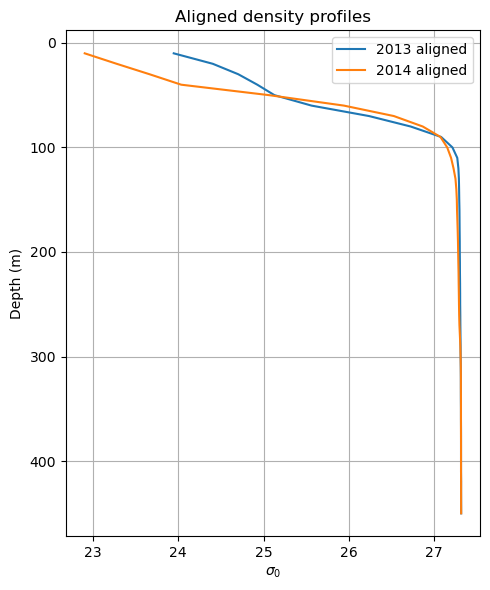


===== k(u) scan results: 2013 -> 2014 =====
 u_depth_input  u_depth_actual          A_u     drho_dz_u  integral_term          k_u
           180           180.0 1.103156e+07  3.456828e-04      -0.495634 1.299709e-04
           190           190.0 1.032265e+07  2.654079e-04      -0.414058 1.511320e-04
           200           200.0 9.663060e+06  2.202478e-04      -0.343699 1.614922e-04
           210           210.0 9.106780e+06  2.353897e-04      -0.281794 1.314559e-04
           220           220.0 8.660759e+06  1.975557e-04      -0.227531 1.329824e-04
           230           230.0 8.282797e+06  1.718722e-04      -0.178897 1.256666e-04
           240           240.0 7.893084e+06  1.779845e-04      -0.134176 9.550944e-05
           250           250.0 7.557366e+06  1.842879e-04      -0.094730 6.801749e-05
           260           260.0 7.191126e+06  2.615852e-04      -0.059551 3.165756e-05
           270           270.0 6.855438e+06  4.337968e-04      -0.029645 9.968622e-06
         

C:\Users\quzho2904\AppData\Local\Temp\ipykernel_4496\2724209698.py:161: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral_term = np.trapz(integrand[valid], z_int[valid])


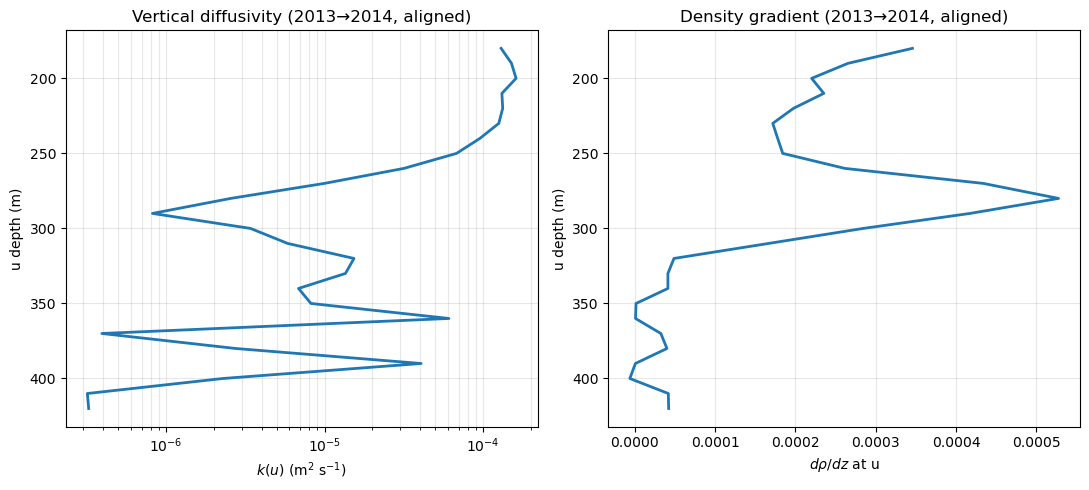

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# 1. Load hypsometry
# =========================================================
def load_hypsometry_csv(hyp_csv):
    df = pd.read_csv(hyp_csv)

    required_cols = ["depth_m", "area_m2"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Hypsometry file missing column: {col}")

    z_hyp = df["depth_m"].to_numpy(dtype=float)
    area_z = df["area_m2"].to_numpy(dtype=float)

    volume_z = None
    if "volume_m3" in df.columns:
        volume_z = df["volume_m3"].to_numpy(dtype=float)

    idx = np.argsort(z_hyp)
    z_hyp = z_hyp[idx]
    area_z = area_z[idx]
    if volume_z is not None:
        volume_z = volume_z[idx]

    return z_hyp, area_z, volume_z, df


# =========================================================
# 2. Load aligned sigma0 profiles and datetimes from CSV
# =========================================================
def load_sigma_station_csv(sig_csv):
    df = pd.read_csv(sig_csv)

    required_cols = [
        "depth_m",
        "sigma0_2013_aligned",
        "sigma0_2014_aligned",
        "datetime_2013",
        "datetime_2014"
    ]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Sigma file missing column: {col}")

    z_obs = df["depth_m"].to_numpy(dtype=float)
    rho_2013 = df["sigma0_2013_aligned"].to_numpy(dtype=float)
    rho_2014 = df["sigma0_2014_aligned"].to_numpy(dtype=float)

    dt2013_series = df["datetime_2013"].dropna()
    dt2014_series = df["datetime_2014"].dropna()

    if len(dt2013_series) == 0 or len(dt2014_series) == 0:
        raise ValueError("Datetime columns exist, but one or more are empty")

    dt_2013 = pd.to_datetime(dt2013_series.iloc[0])
    dt_2014 = pd.to_datetime(dt2014_series.iloc[0])

    return z_obs, rho_2013, rho_2014, dt_2013, dt_2014, df


# =========================================================
# 3. Interpolate profile onto hypsometry grid
# =========================================================
def interp_profile_to_grid(z_obs, rho_obs, z_grid):
    z_obs = np.asarray(z_obs, dtype=float)
    rho_obs = np.asarray(rho_obs, dtype=float)
    z_grid = np.asarray(z_grid, dtype=float)

    mask = np.isfinite(z_obs) & np.isfinite(rho_obs)
    z_obs = z_obs[mask]
    rho_obs = rho_obs[mask]

    if len(z_obs) < 2:
        raise ValueError("Not enough valid observations for interpolation")

    idx = np.argsort(z_obs)
    z_obs = z_obs[idx]
    rho_obs = rho_obs[idx]

    rho_grid = np.interp(z_grid, z_obs, rho_obs, left=np.nan, right=np.nan)

    zmin = np.nanmin(z_obs)
    zmax = np.nanmax(z_obs)
    rho_grid[(z_grid < zmin) | (z_grid > zmax)] = np.nan

    return rho_grid


# =========================================================
# 4. Simple smoothing
# =========================================================
def moving_average_nan(x, window=3):
    x = np.asarray(x, dtype=float)
    y = np.full_like(x, np.nan)

    half = window // 2
    for i in range(len(x)):
        i0 = max(0, i - half)
        i1 = min(len(x), i + half + 1)
        seg = x[i0:i1]
        if np.isfinite(seg).sum() > 0:
            y[i] = np.nanmean(seg)

    return y


# =========================================================
# 5. Compute k for a single u depth
# =========================================================
def compute_vertical_diffusivity_single_u(
    z_grid,
    area_z,
    rho_t1,
    rho_t2,
    delta_t_days,
    u_depth,
    smooth_window=1,
    use_abs_value=True
):
    z_grid = np.asarray(z_grid, dtype=float)
    area_z = np.asarray(area_z, dtype=float)
    rho_t1 = np.asarray(rho_t1, dtype=float)
    rho_t2 = np.asarray(rho_t2, dtype=float)

    delta_t_sec = delta_t_days * 24 * 3600.0

    rho1_s = moving_average_nan(rho_t1, window=smooth_window)
    rho2_s = moving_average_nan(rho_t2, window=smooth_window)

    drho_dt = (rho2_s - rho1_s) / delta_t_sec

    u_index = np.argmin(np.abs(z_grid - u_depth))
    u_depth_actual = z_grid[u_index]

    drho_dz = np.gradient(rho2_s, z_grid)
    drho_dz_u = drho_dz[u_index]

    A_u = area_z[u_index]

    mask_int = z_grid >= u_depth_actual
    z_int = z_grid[mask_int]
    integrand = area_z[mask_int] * drho_dt[mask_int]

    valid = np.isfinite(z_int) & np.isfinite(integrand)

    if valid.sum() < 2:
        return {
            "u_depth_input": u_depth,
            "u_depth_actual": u_depth_actual,
            "A_u": A_u,
            "drho_dz_u": drho_dz_u,
            "integral_term": np.nan,
            "k_u": np.nan
        }

    integral_term = np.trapz(integrand[valid], z_int[valid])

    denominator = A_u * drho_dz_u

    if (not np.isfinite(denominator)) or (denominator == 0):
        k_u = np.nan
    else:
        k_u = integral_term / denominator
        if use_abs_value:
            k_u = np.abs(k_u)

    return {
        "u_depth_input": u_depth,
        "u_depth_actual": u_depth_actual,
        "A_u": A_u,
        "drho_dz_u": drho_dz_u,
        "integral_term": integral_term,
        "k_u": k_u
    }


# =========================================================
# 6. Scan multiple u depths
# =========================================================
def scan_u_depths(
    z_grid,
    area_z,
    rho_t1,
    rho_t2,
    delta_t_days,
    u_depth_list,
    smooth_window=1,
    use_abs_value=True
):
    results = []

    for u in u_depth_list:
        res = compute_vertical_diffusivity_single_u(
            z_grid=z_grid,
            area_z=area_z,
            rho_t1=rho_t1,
            rho_t2=rho_t2,
            delta_t_days=delta_t_days,
            u_depth=u,
            smooth_window=smooth_window,
            use_abs_value=use_abs_value
        )
        results.append(res)

    return pd.DataFrame(results)


# =========================================================
# 7. Plot density profiles
# =========================================================
def plot_density_profiles(z_grid, rho2013_grid, rho2014_grid, smooth_window=1):
    rho2013_s = moving_average_nan(rho2013_grid, window=smooth_window)
    rho2014_s = moving_average_nan(rho2014_grid, window=smooth_window)

    plt.figure(figsize=(5, 6))
    plt.plot(rho2013_grid, z_grid, label="2013 aligned")
    plt.plot(rho2014_grid, z_grid, label="2014 aligned")

    # plt.plot(rho2013_s, z_grid, "--", label="2013 smooth")
    # plt.plot(rho2014_s, z_grid, "--", label="2014 smooth")

    plt.gca().invert_yaxis()
    plt.xlabel(r"$\sigma_0$")
    plt.ylabel("Depth (m)")
    plt.title("Aligned density profiles")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()


# =========================================================
# 8. Plot scan results
# =========================================================
def plot_scan_results(df_scan, title_suffix="", save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))

    mask_k = np.isfinite(df_scan["k_u"]) & (df_scan["k_u"] > 0)

    axes[0].plot(
        df_scan.loc[mask_k, "k_u"],
        df_scan.loc[mask_k, "u_depth_actual"],
        "-",
        linewidth=2
    )
    axes[0].set_xscale("log")
    axes[0].invert_yaxis()
    axes[0].set_xlabel(r"$k(u)$ (m$^2$ s$^{-1}$)")
    axes[0].set_ylabel("u depth (m)")
    axes[0].set_title(f"Vertical diffusivity {title_suffix}")
    axes[0].grid(True, which="both", alpha=0.3)

    axes[1].plot(
        df_scan["drho_dz_u"],
        df_scan["u_depth_actual"],
        "-",
        linewidth=2
    )
    axes[1].invert_yaxis()
    axes[1].set_xlabel(r"$d\rho/dz$ at u")
    axes[1].set_ylabel("u depth (m)")
    axes[1].set_title(f"Density gradient {title_suffix}")
    axes[1].grid(True, which="both", alpha=0.3)

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


# =========================================================
# 9. Main program
# =========================================================
if __name__ == "__main__":

    hyp_csv = r"C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\hypsometry_dz10m_lonLE5.30.csv"
    sig_csv = r"C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\sigma0_station1084_2013_vs_station389_2014_aligned.csv"

    # -----------------------------------------------------
    # Load data
    # -----------------------------------------------------
    z_hyp, area_z, volume_z, df_hyp = load_hypsometry_csv(hyp_csv)
    z_obs, rho2013_obs, rho2014_obs, dt_2013, dt_2014, df_sig = load_sigma_station_csv(sig_csv)

    # -----------------------------------------------------
    # Compute dt automatically from file
    # -----------------------------------------------------
    delta_t_days_2013_2014 = (dt_2014 - dt_2013).total_seconds() / 86400.0

    if delta_t_days_2013_2014 <= 0:
        raise ValueError("Computed delta_t_days is non-positive. Check datetime order in the file.")

    print(f"datetime_2013 = {dt_2013}")
    print(f"datetime_2014 = {dt_2014}")
    print(f"delta_t_days_2013_2014 = {delta_t_days_2013_2014:.3f}")

    # -----------------------------------------------------
    # Interpolate onto hypsometry grid
    # -----------------------------------------------------
    rho2013_grid = interp_profile_to_grid(z_obs, rho2013_obs, z_hyp)
    rho2014_grid = interp_profile_to_grid(z_obs, rho2014_obs, z_hyp)

    # -----------------------------------------------------
    # Parameters
    # -----------------------------------------------------
    smooth_window = 1
    u_depth_list = np.arange(180, 430, 10)

    # -----------------------------------------------------
    # Plot profiles
    # -----------------------------------------------------
    plot_density_profiles(
        z_hyp,
        rho2013_grid,
        rho2014_grid,
        smooth_window=smooth_window
    )

    # -----------------------------------------------------
    # Scan 2013 -> 2014
    # -----------------------------------------------------
    df_scan_2013_2014 = scan_u_depths(
        z_grid=z_hyp,
        area_z=area_z,
        rho_t1=rho2013_grid,
        rho_t2=rho2014_grid,
        delta_t_days=delta_t_days_2013_2014,
        u_depth_list=u_depth_list,
        smooth_window=smooth_window,
        use_abs_value=True
    )

    # -----------------------------------------------------
    # Remove selected u-depth results
    # -----------------------------------------------------
    # Example:
    # df_scan_2013_2014 = df_scan_2013_2014[
    #     ~np.isclose(df_scan_2013_2014["u_depth_actual"], 380)
    # ].reset_index(drop=True)

    # -----------------------------------------------------
    # Print results
    # -----------------------------------------------------
    print("\n===== k(u) scan results: 2013 -> 2014 =====")
    print(df_scan_2013_2014.to_string(index=False))

    # -----------------------------------------------------
    # Save results
    # -----------------------------------------------------
    save_csv_2013_2014 = r"C:\Users\quzho2904\OneDrive - University of Bergen\GEOF337\report\mixing_scan_u_station1084_2013_vs_station389_2014_aligned.csv"

    df_scan_2013_2014.to_csv(save_csv_2013_2014, index=False, encoding="utf-8-sig")

    print(f"\nSaved 2013->2014 scan results to:\n{save_csv_2013_2014}")

    # -----------------------------------------------------
    # Plot scan results
    # -----------------------------------------------------
    plot_scan_results(df_scan_2013_2014, title_suffix="(2013→2014, aligned)")